## Diagrama y código base 

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def f(x, a):
    return a * x * (1 - x)


def orbita(a, x0, n_iter, n_desechar=0):
    """Órbita x_0, ..., x_{n_iter} tras descartar las primeras n_desechar iteraciones."""
    x = x0
    for _ in range(n_desechar):
        x = f(x, a)

    xs = np.empty(n_iter + 1)
    xs[0] = x
    for n in range(n_iter):
        xs[n + 1] = f(xs[n], a)
    return xs


def cobweb(ax, a, x0, n_pasos=60, n_final=None, n_desechar=0):
    """Dibuja el diagrama cobweb sobre el eje ax, resaltando los ultimos n_final pasos."""
    u = np.linspace(0, 1, 500)
    ax.plot(u, f(u, a), color="tab:blue", lw=1.6, label=r"$f(x)=ax(1-x)$")
    ax.plot(u, u, color="0.3", lw=1.0, label=r"$y=x$")

    x = x0
    for _ in range(n_desechar):
        x = f(x, a)

    if n_final is None:
        n_final = n_pasos

    # Primer tramo vertical: desde el eje hasta la parábola
    ax.plot([x, x], [0, f(x, a)], color="0.72", lw=0.7)

    # Cada paso: horizontal hasta la diagonal, vertical hasta la parábola.
    # El transitorio va en gris y los últimos n_final pasos en rojo, para que
    # el ciclo final no quede enterrado bajo el camino de llegada.
    for k in range(n_pasos):
        y = f(x, a)
        if k >= n_pasos - n_final:
            color, ancho, z = "tab:red", 1.2, 3
        else:
            color, ancho, z = "0.72", 0.7, 2
        ax.plot([x, y], [y, y], color=color, lw=ancho, zorder=z)
        ax.plot([y, y], [y, f(y, a)], color=color, lw=ancho, zorder=z)
        x = y

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_n$")
    ax.set_ylabel(r"$x_{n+1}$")


def bifurcaciones(ax, a_min, a_max, n_a=1000, n_transitorio=500, n_plot=200,
                  x0=0.5, alpha=0.15):
    """Diagrama de bifurcaciones sobre el eje ax, iterando todos los a a la vez."""
    a = np.linspace(a_min, a_max, n_a)
    x = np.full(n_a, x0)

    # Eliminar transitorio
    for _ in range(n_transitorio):
        x = a * x * (1 - x)

    # Dibujar últimas iteraciones
    for _ in range(n_plot):
        x = a * x * (1 - x)
        ax.plot(a, x, ",k", alpha=alpha)

    ax.set_xlim(a_min, a_max)
    ax.set_xlabel(r"$a$", fontsize=13)
    ax.set_ylabel(r"$x$", fontsize=13)

## 1. Ejercicio 1: Cuatro valores

Usamos la misma condición inicial $x_0 = 0.2$, lo que cambia es $a$:

Para cada valor grafico la serie temporal $x_n$ contra $n$ y, al lado, el cobweb correspondiente.

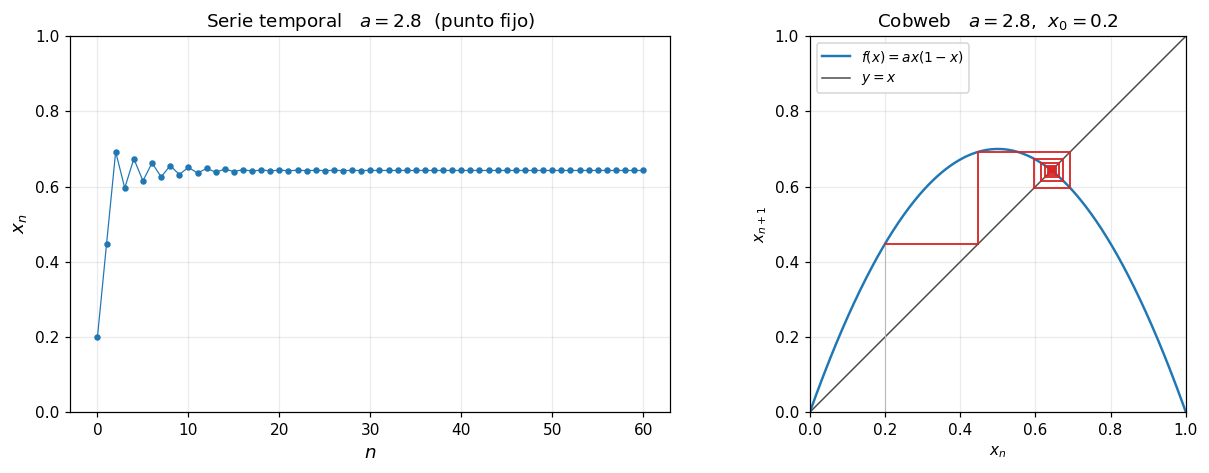

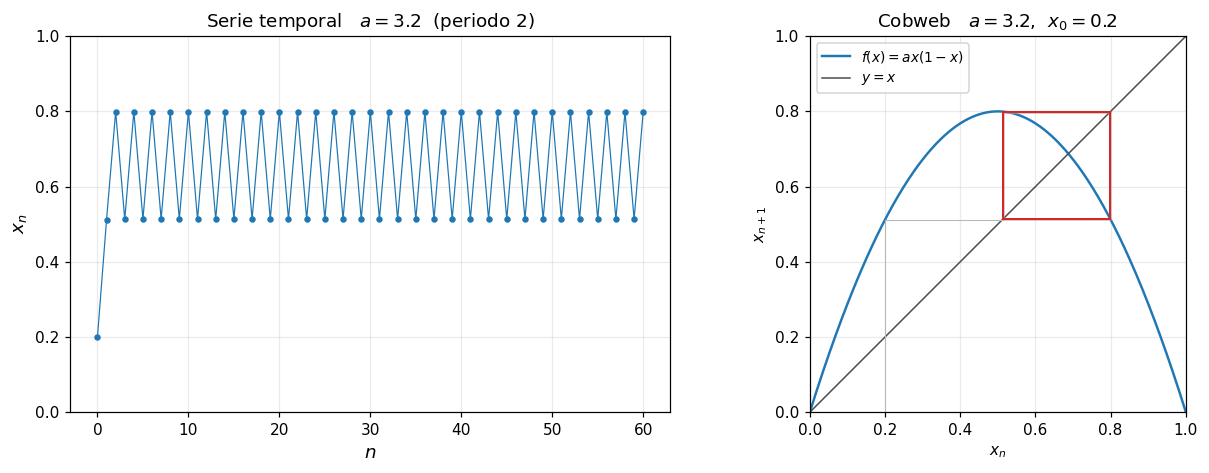

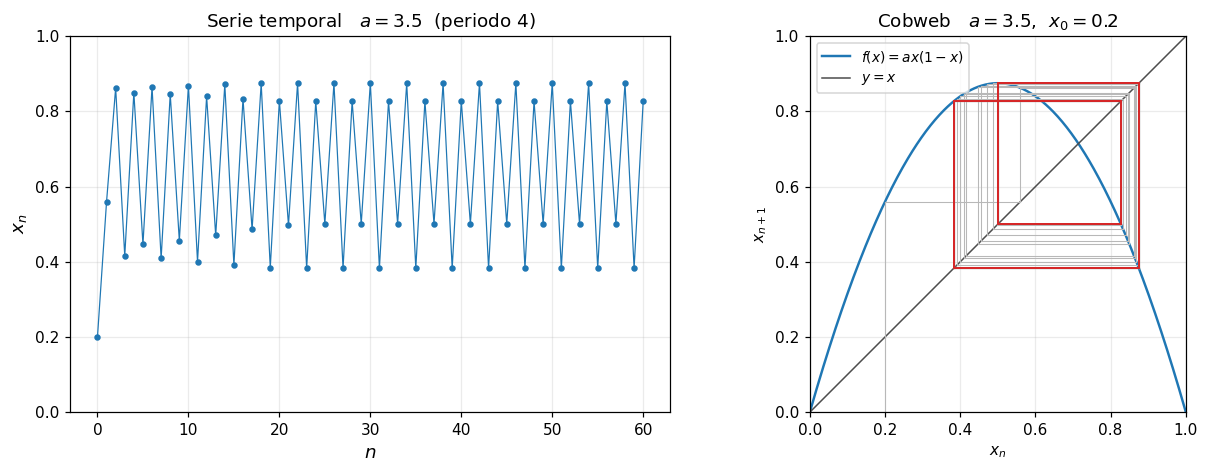

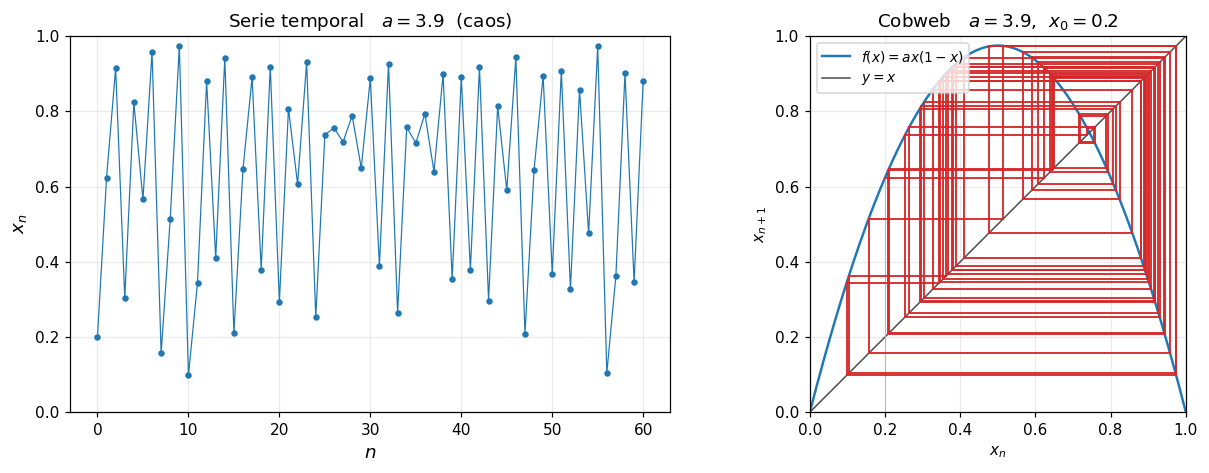

In [45]:
#   a    x0   etiqueta       pasos del cobweb, de ellos resaltados
casos = [
    (2.8, 0.2, "punto fijo", 18, 18),
    (3.2, 0.2, "periodo 2", 60, 10),
    (3.5, 0.2, "periodo 4", 60, 16),
    (3.9, 0.2, "caos", 60, 60),
]

for a, x0, etiqueta, n_pasos, n_final in casos:
    xs = orbita(a, x0, 60)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

    ax1.plot(xs, "o-", ms=3.2, lw=0.8, color="tab:blue")
    ax1.set_xlabel("$n$", fontsize=12)
    ax1.set_ylabel("$x_n$", fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.set_title(f"Serie temporal   $a={a}$  ({etiqueta})")

    cobweb(ax2, a, x0, n_pasos=n_pasos, n_final=n_final)
    ax2.set_title(f"Cobweb   $a={a}$,  $x_0={x0}$")
    ax2.legend(loc="upper left", fontsize=9)

    fig.tight_layout()
    plt.show()

In [46]:
print("   a    valores del atractor (iteraciones 2001 a 2008)")
for a, x0, etiqueta, _, _ in casos:
    cola = orbita(a, x0, 7, n_desechar=2000)
    print(f"{a:5.2f}   " + "  ".join(f"{v:.4f}" for v in cola) + f"   <- {etiqueta}")

# Estabilidad del punto fijo no trivial: x* = 1 - 1/a  y  f'(x*) = 2 - a
print("\nDerivada en el punto fijo x* = 1 - 1/a:")
for a in [2.8, 3.0, 3.2]:
    xf = 1 - 1 / a
    d = a - 2 * a * xf
    estado = "atractor" if abs(d) < 1 else "repulsor"
    print(f"  a = {a:.1f}:  x* = {xf:.4f},  f'(x*) = {d:+.3f},  |f'(x*)| = {abs(d):.3f}  -> {estado}")

   a    valores del atractor (iteraciones 2001 a 2008)
 2.80   0.6429  0.6429  0.6429  0.6429  0.6429  0.6429  0.6429  0.6429   <- punto fijo
 3.20   0.7995  0.5130  0.7995  0.5130  0.7995  0.5130  0.7995  0.5130   <- periodo 2
 3.50   0.8269  0.5009  0.8750  0.3828  0.8269  0.5009  0.8750  0.3828   <- periodo 4
 3.90   0.2687  0.7663  0.6984  0.8214  0.5721  0.9548  0.1685  0.5464   <- caos

Derivada en el punto fijo x* = 1 - 1/a:
  a = 2.8:  x* = 0.6429,  f'(x*) = -0.800,  |f'(x*)| = 0.800  -> atractor
  a = 3.0:  x* = 0.6667,  f'(x*) = -1.000,  |f'(x*)| = 1.000  -> repulsor
  a = 3.2:  x* = 0.6875,  f'(x*) = -1.200,  |f'(x*)| = 1.200  -> repulsor


EN $a = 3.9$, comparemos las dos órbitas que arrancan con una diferencia de $10^{-4}$.

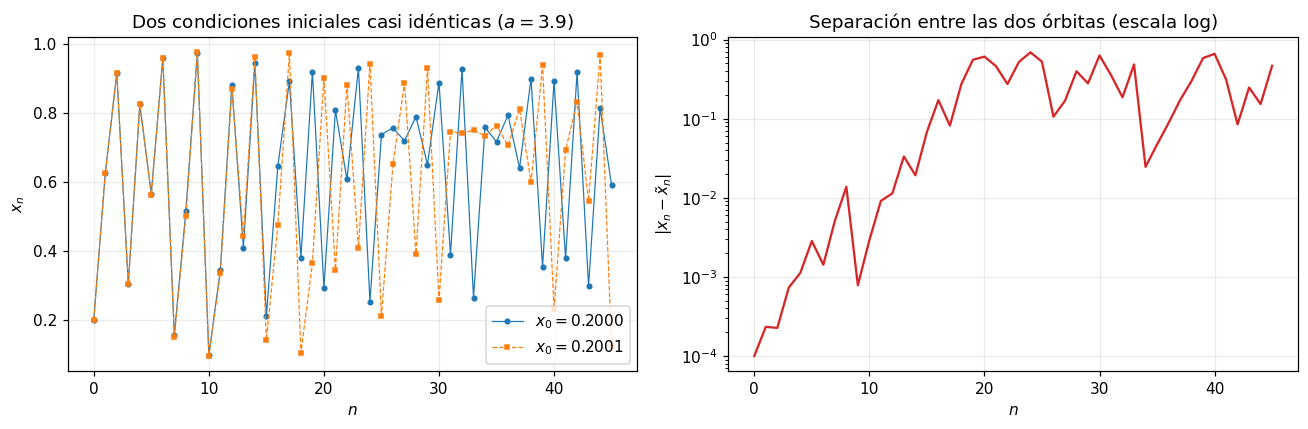

La diferencia inicial de 1e-4 supera 0.1 en la iteración n = 16


In [47]:
a = 3.9
x1 = orbita(a, 0.2000, 45)
x2 = orbita(a, 0.2001, 45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x1, "o-", ms=3, lw=0.8, label="$x_0 = 0.2000$")
ax1.plot(x2, "s--", ms=3, lw=0.8, label="$x_0 = 0.2001$")
ax1.set_xlabel("$n$")
ax1.set_ylabel("$x_n$")
ax1.set_title("Dos condiciones iniciales casi idénticas ($a = 3.9$)")
ax1.legend()

ax2.semilogy(np.abs(x1 - x2), color="tab:red")
ax2.set_xlabel("$n$")
ax2.set_ylabel(r"$|x_n - \tilde{x}_n|$")
ax2.set_title("Separación entre las dos órbitas (escala log)")

fig.tight_layout()
plt.show()

n_sep = np.argmax(np.abs(x1 - x2) > 0.1)
print(f"La diferencia inicial de 1e-4 supera 0.1 en la iteración n = {n_sep}")

Localicemos los 4 valores en el diagrama de bifurcaciones 

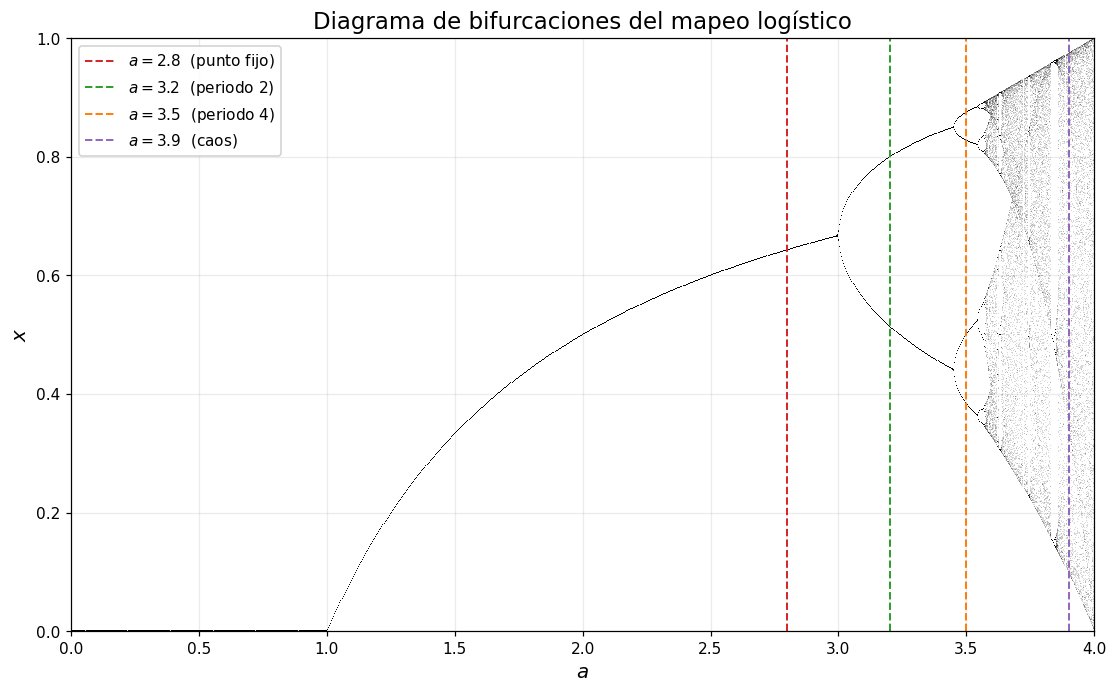

In [48]:
fig, ax = plt.subplots(figsize=(12, 7))
bifurcaciones(ax, 0, 4, n_a=1000, n_plot=200)
ax.set_ylim(0, 1)

colores = ["tab:red", "tab:green", "tab:orange", "tab:purple"]
for (a, _, etiqueta, _, _), color in zip(casos, colores):
    ax.axvline(a, color=color, lw=1.3, ls="--", label=f"$a={a}$  ({etiqueta})")

ax.set_title("Diagrama de bifurcaciones del mapeo logístico", fontsize=15)
ax.legend(loc="upper left", framealpha=0.9)
plt.show()

### 2. Lo que se observa en cada caso y comparando las tres representaciones 

Con $a = 2.8$ la serie temporal se aplana en unas quince iteraciones y después ya no se distingue
ningún movimiento: la órbita se queda en $x^{*} \approx 0.6429$, que es exactamente $1 - 1/a$. En el coweb similar con diferente trayectoria. Lo que se ve sólo en el coweb es que la convergencia es oscilante: los puntos caen alternadamente arriba y abajo del valor final.

Al subir a $a = 3.2$ el punto fijo sigue existiendo pero ya no atrae: ahí $|f'(x^{*})| = 1.2 > 1$.
La órbita salta entre $0.5130$ y $0.7995$ sin quedarse en ninguno, y en el cobweb la trayectoria
deja de espiralar y se cierra en un rectángulo que se recorre una y otra vex. 

En $a = 3.5$ pasa lo mismo pero con cuatro valores: $0.3828$, $0.8269$, $0.5009$ y $0.8750$. En la
serie temporal cuesta contarlos porque dos están muy cerca; en el cobweb el ciclo aparece como una
figura cerrada de cuatro esquinas apoyadas en la diagonal, así el coweb indica qué es periódico y los periodos específicos. 

El caso $a = 3.9$ es naturalmente distinto. La serie temporal no se asienta nunca y el
cobweb se vuelve una especie de convergencia que llena la región. Respecto a las dos condiciones iniciales: una diferencia de $10^{-4}$ crece exponencialmente y, en dieciséis iteraciones, las órbitas ya se separan más de $0.1$, con la misma regla determinista.

En el diagrama de bifurcaciones las cuatro líneas verticales cortan al atractor en tantos puntos
como valores tiene: uno en $2.8$, dos en $3.2$, cuatro en $3.5$ y una nube continua en $3.9$. Es decir, resume heurísticamente lo anterioer. 

Así, las tres representaciones muestran aspectos distintos de la misma dinámica. La serie temporal permite ver cómo evoluciona $x_n$ con $n$: un punto fijo aparece cuando la órbita converge a un solo valor, una órbita periódica cuando se repite una secuencia y el caos cuando no se observa un periodo claro. El cobweb muestra geométricamente cómo se generan las iteraciones: converge a una intersección entre $f(x)$ y $y=x$ en un punto fijo, forma ciclos en casos periódicos y recorre muchos puntos en casos caóticos. El diagrama de bifurcaciones resume el comportamiento de largo plazo al variar $a$: una rama indica un punto fijo, varias ramas indican periodicidad y una banda densa sugiere caos; por eso es la representación más útil para observar cómo cambia globalmente la dinámica al modificar $a$.


## 2. Comparación de las tres representaciones

|  | serie temporal | cobweb | bifurcaciones |
|:--|:--|:--|:--|
| ¿hay punto fijo? | sí, cuando la curva se aplana | sí, y además se ve *por qué*: el corte con la diagonal | sí, cuando el atractor es una sola rama |
| ¿es periódica? | sí, si el patrón se repite | sí, la órbita cierra un polígono | sí, si hay un número finito de ramas |
| ¿qué periodo? | contando, y solo si es corto | contando esquinas; cómodo hasta 4 u 8 | contando ramas, hasta donde alcance la resolución |
| ¿parece caótica? | indicio: no se repite nunca | indicio: la telaraña llena una región | sí, banda vertical continua |
| ¿cómo cambia con $a$? | hay que rehacer la gráfica para cada $a$ | hay que rehacer la gráfica para cada $a$ | está todo en una sola imagen |

Las tres responden preguntas distintas y ninguna sustituye del todo a las otras. La serie temporal
es la más honesta sobre lo que de verdad hace la órbita: es la única donde se ve el transitorio, es
decir, cuánto tarda el sistema en llegar a su comportamiento final y en qué orden visita los puntos
del ciclo. A cambio es la peor para diagnosticar, porque a partir de periodo 8 más o menos ya no
distingo un ciclo largo de algo aperiódico.

El cobweb es la única de las tres que muestra el mecanismo en lugar del resultado. La pregunta "¿por
qué el punto fijo deja de atraer en $a = 3$?" no se contesta con una serie temporal, pero en el
cobweb es geometría elemental: cuando la parábola cruza la diagonal con pendiente más inclinada que
la diagonal misma, la espiral se abre en lugar de cerrarse. Su desventaja es que muestra un solo
valor de $a$ a la vez y que, si el periodo es alto, la figura cerrada se vuelve ilegible.

El diagrama de bifurcaciones sacrifica toda la información temporal (no dice cuánto tarda ni en qué
orden se visitan los puntos) a cambio de mostrar el parámetro completo de un tirón. Es el único
lugar donde se ve que las duplicaciones de periodo forman una cascada, que existen ventanas
periódicas dentro del caos y que el atractor cambia de manera continua entre bifurcaciones. Para mí
la conclusión práctica es que el bifurcaciones sirve para saber *dónde mirar*, y las otras dos para
entender *qué está pasando* ahí.

## 3. Ejercicio 3: Transición hacia el caos

Veamos la gráfica del rango $a \in [2.5, 4]$. 

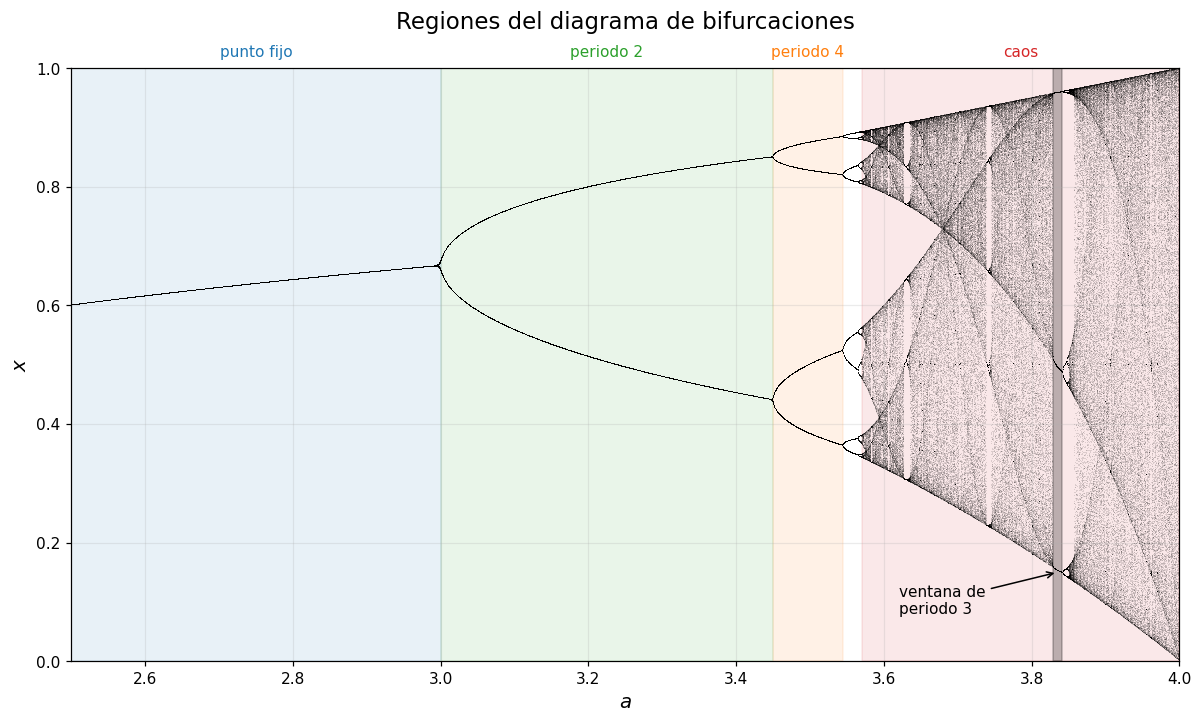

In [36]:
fig, ax = plt.subplots(figsize=(13, 7))
bifurcaciones(ax, 2.5, 4.0, n_a=3000, n_transitorio=600, n_plot=250, alpha=0.12)
ax.set_ylim(0, 1)

regiones = [
    (2.5, 3.0, "tab:blue", "punto fijo"),
    (3.0, 3.4495, "tab:green", "periodo 2"),
    (3.4495, 3.5441, "tab:orange", "periodo 4"),
    (3.5699, 4.0, "tab:red", "caos"),
]

for a_i, a_f, color, nombre in regiones:
    ax.axvspan(a_i, a_f, color=color, alpha=0.10)
    ax.text((a_i + a_f) / 2, 1.02, nombre, ha="center", fontsize=10, color=color)

# Ventana de periodo 3 dentro de la zona caótica
ax.axvspan(3.8284, 3.8415, color="k", alpha=0.25)
ax.annotate("ventana de\nperiodo 3", xy=(3.835, 0.15), xytext=(3.62, 0.08),
            fontsize=10, arrowprops=dict(arrowstyle="->", lw=1))

ax.set_title("Regiones del diagrama de bifurcaciones", fontsize=15, pad=26)
plt.show()

Expliquenmos los bordes de la gráfica: El primero es analítico
($a = 3$, donde $|f'(x^{*})| = 1$) y el segundo también ($a = 1 + \sqrt{6}$). Los demás se verifcan numéricamente 

In [37]:
def periodo_detectado(a, x0=0.31, n_desechar=4000, n_prueba=200, tol=1e-6, p_max=64):
    """Menor p <= p_max tal que la órbita se repite cada p pasos; None si no lo encuentra."""
    xs = orbita(a, x0, n_prueba, n_desechar=n_desechar)
    for p in range(1, p_max + 1):
        if np.max(np.abs(xs[p:] - xs[:-p])) < tol:
            return p
    return None


print(f"1 + sqrt(6) = {1 + np.sqrt(6):.4f}\n")
print("    a     periodo detectado")
for a in [2.80, 3.20, 3.45, 3.50, 3.55, 3.5699, 3.83, 3.90, 4.00]:
    p = periodo_detectado(a)
    print(f"  {a:6.4f}   {p if p is not None else 'no periódico (p > 64)'}")

1 + sqrt(6) = 3.4495

    a     periodo detectado
  2.8000   1
  3.2000   2
  3.4500   4
  3.5000   4
  3.5500   8
  3.5699   no periódico (p > 64)
  3.8300   3
  3.9000   no periódico (p > 64)
  4.0000   no periódico (p > 64)


In [38]:
# ¿Dónde empieza y dónde termina la ventana de periodo 3?
rejilla = np.linspace(3.80, 3.87, 351)
con_periodo_3 = [a for a in rejilla if periodo_detectado(a, n_desechar=3000, n_prueba=100) == 3]

print(f"Ventana de periodo 3 aproximada:  a en [{min(con_periodo_3):.4f}, {max(con_periodo_3):.4f}]")
print(f"Ancho de la ventana: {max(con_periodo_3) - min(con_periodo_3):.4f}")

Ventana de periodo 3 aproximada:  a en [3.8286, 3.8412]
Ancho de la ventana: 0.0126


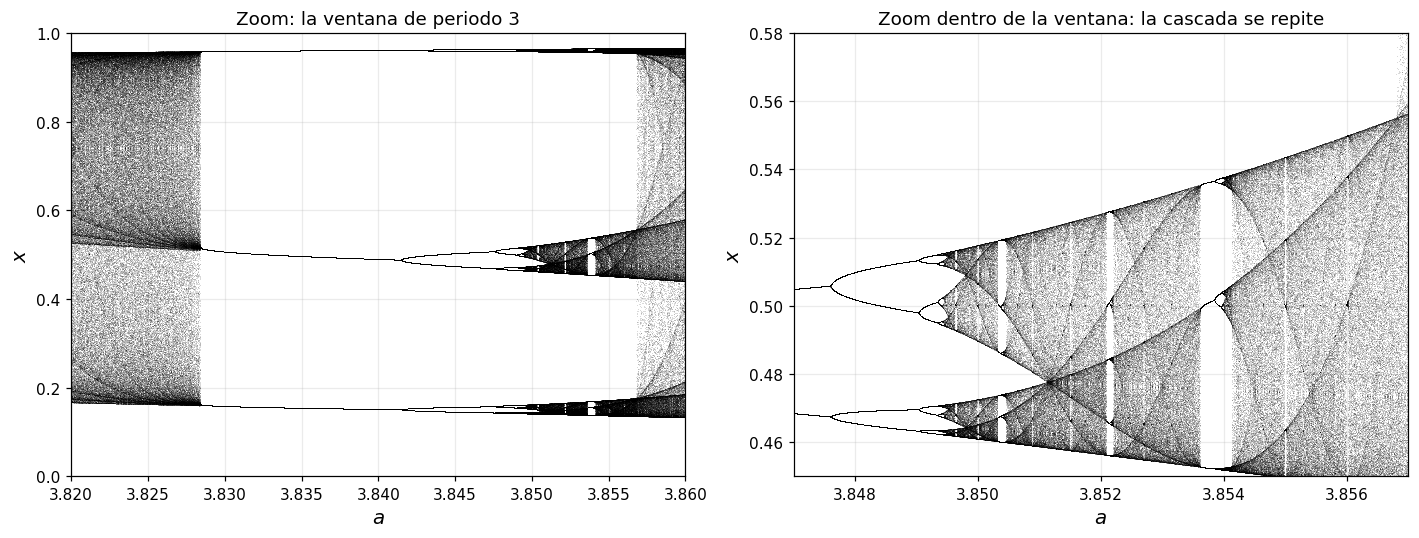

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bifurcaciones(ax1, 3.82, 3.86, n_a=3000, n_transitorio=1000, n_plot=300, alpha=0.15)
ax1.set_ylim(0, 1)
ax1.set_title("Zoom: la ventana de periodo 3")

bifurcaciones(ax2, 3.847, 3.857, n_a=3000, n_transitorio=1500, n_plot=400, alpha=0.15)
ax2.set_ylim(0.45, 0.58)
ax2.set_title("Zoom dentro de la ventana: la cascada se repite")

fig.tight_layout()
plt.show()

### Lo que dice la transición

En general, la secuencia de duplicaciones no es lineal: el periodo 2 va de $3$ a $3.4495$ (ancho $0.449$), el 4 hasta $3.5441$ (ancho $0.095$) y el 8 apenas hasta $3.5644$ (ancho $0.020$), cada tramo unas $4.7$ veces menor que el anterior, así que los infinitos periodos $2^k$ caben en un intervalo finito y se acumulan en $a_\infty \approx 3.5699$: antes el atractor es finito, después ya no. Lo menos intuitivo es lo que sigue, porque la zona $a > 3.5699$ no se vuelve más desordenada de manera
monótona: hay periodo 3 en $a \approx 3.83$, en pleno territorio caótico, y la ventana mide unos
$0.013$ de ancho, un intervalo entero donde el sistema visita solo tres estados; dentro de ella
aparece otra cascada $3 \to 6 \to 12$ que reproduce en miniatura el diagrama completo. Así, el orrden y el caos no están separados por un valor umbral sino intercalados, pero el conjunto caótico crece cada vez más. 

## 4. Ejercicio 4: El conjunto de Mandelbrot

Ahora iteremos: 

$$z_{n+1} = z_n^2 + c, \qquad z_0 = 0,$$

con $c$ complejo, y coloreemos cada $c$ según cuántas iteraciones tarda en cumplir $|z_n| > 2$ (en cuanto el módulo pasa de 2, la órbita se va a infinito). Los puntos que nunca escapan dentro del máximo de iteraciones vienen de color negro: ese
conjunto es el de Mandelbrot. La valoración es vectorizada

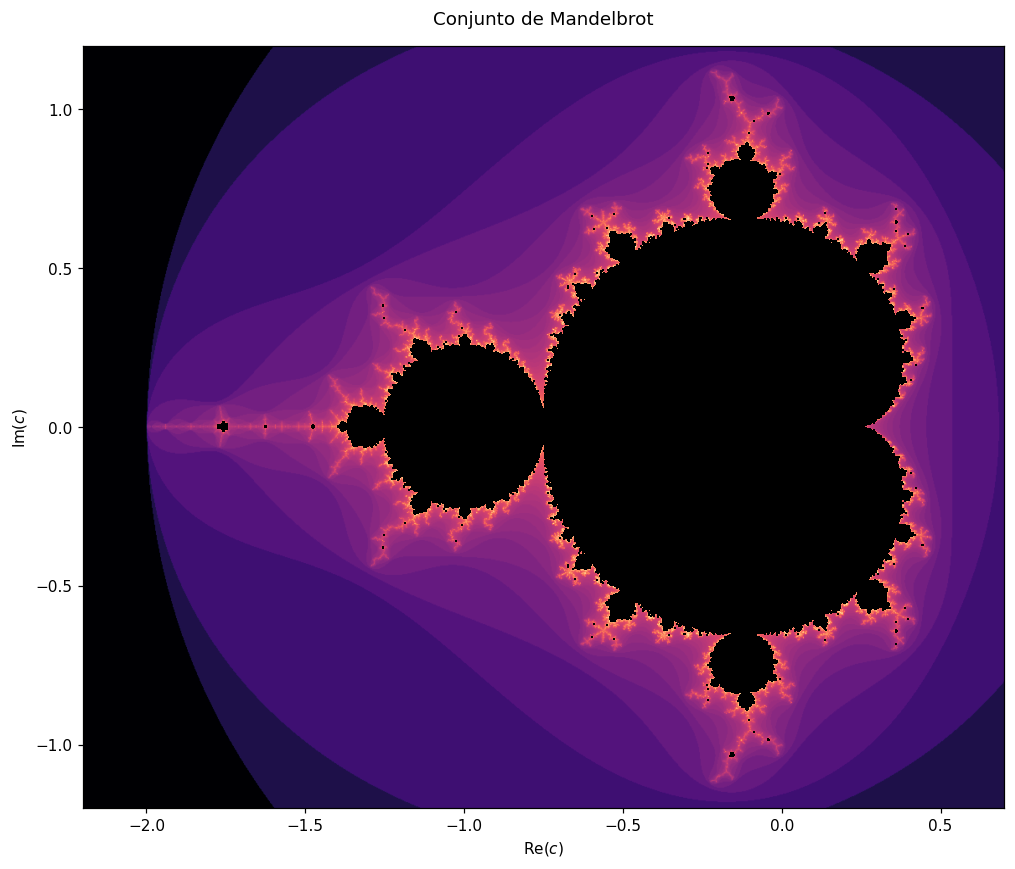

In [40]:
def mandelbrot(re_min, re_max, im_min, im_max, ancho=1000, alto=750, max_iter=200):
    """Escape-time: devuelve la iteración en la que |z| supera 2 (max_iter si no escapa)."""
    re = np.linspace(re_min, re_max, ancho)
    im = np.linspace(im_min, im_max, alto)
    C = re[np.newaxis, :] + 1j * im[:, np.newaxis]

    Z = np.zeros_like(C)
    escape = np.full(C.shape, max_iter, dtype=int)
    activos = np.ones(C.shape, dtype=bool)

    for n in range(max_iter):
        Z[activos] = Z[activos] ** 2 + C[activos]
        fuera = activos & (np.abs(Z) > 2)
        escape[fuera] = n
        activos &= ~fuera

    return escape


def dibujar(ax, escape, extent, max_iter=200, titulo=""):
    # Escala logarítmica: fuera del conjunto casi todo escapa en muy pocas
    # iteraciones, y en escala lineal el dibujo sale prácticamente todo negro.
    img = np.ma.masked_where(escape == max_iter, np.log1p(escape))
    cmap = plt.cm.magma.copy()
    cmap.set_bad("black")           # el interior del conjunto
    ax.imshow(img, extent=extent, origin="lower", cmap=cmap,
              interpolation="bilinear", aspect="auto")
    ax.set_xlabel(r"Re$(c)$")
    ax.set_ylabel(r"Im$(c)$")
    ax.set_title(titulo, pad=14)
    ax.grid(False)


extent = (-2.2, 0.7, -1.2, 1.2)
esc = mandelbrot(*extent, ancho=1100, alto=900, max_iter=200)

fig, ax = plt.subplots(figsize=(11, 9))
dibujar(ax, esc, extent, 200, "Conjunto de Mandelbrot")
ax.set_aspect("equal")
plt.show()

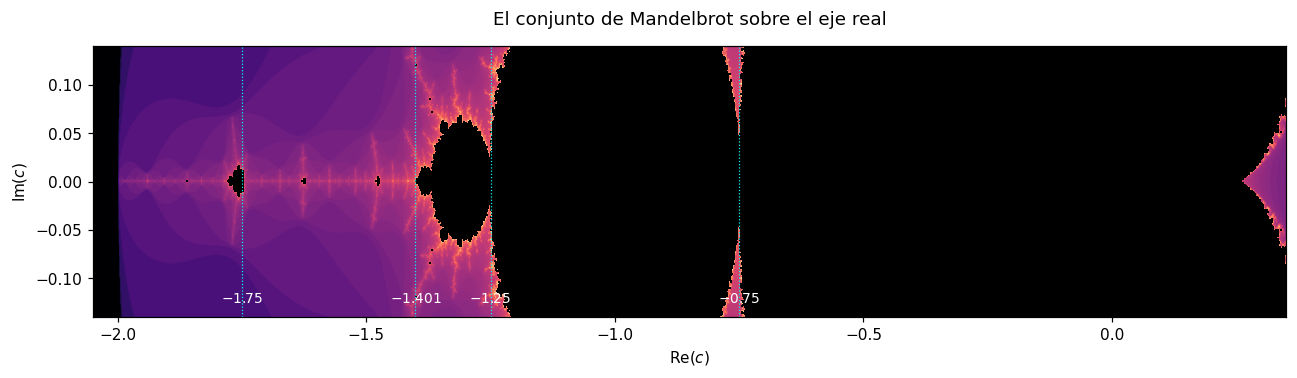

In [ ]:
# Franja delgada alrededor del eje real, que se compara con el mapeo logístico
extent_r = (-2.05, 0.35, -0.14, 0.14)
esc_r = mandelbrot(*extent_r, ancho=1600, alto=300, max_iter=400)

fig, ax = plt.subplots(figsize=(14, 3.2))
dibujar(ax, esc_r, extent_r, 400, "Conjunto de Mandelbrot sobre el eje real")

for c_marca, nombre in [(-0.75, "$-0.75$"), (-1.25, "$-1.25$"),
                        (-1.401, "$-1.401$"), (-1.75, "$-1.75$")]:
    ax.axvline(c_marca, color="cyan", lw=0.8, ls=":")
    ax.text(c_marca, -0.125, nombre, ha="center", color="w", fontsize=9)

plt.show()

Sobre el eje real el conjunto es, en términos de construcción, una sucesión de piezas pegadas una tras
otra: primero la cardioide grande, que termina en $c = -0.75$; luego un disco que va de $-0.75$ a
$-1.25$; luego piezas cada vez más pequeñas que se acumulan cerca de $c \approx -1.401$; y después
de esa acumulación una zona filamentosa donde aparecen, aislados, algunos bulbos grandes. El más
visible de todos está alrededor de $c = -1.75$. El conjunto termina en $c = -2$.

Los tamaños de esas piezas se van reduciendo en la misma proporción con la que se acortaban los
tramos de periodo $2^k$ del mapeo logístico, y el bulbo aislado de $c \approx -1.75$ aparece
después de la acumulación igual que la ventana de periodo 3 aparecía después de $a_\infty$.

## 5. Ejercicio 5: Comparación de Mandelbrot con el mapeo logístico.

### Cambio de variable

Tenemos que

$$z_n = a\left(\tfrac{1}{2} - x_n\right) \qquad \Longrightarrow \qquad x_n = \tfrac{1}{2} - \frac{z_n}{a}.$$

El producto que aparece en el mapeo logístico se factoriza como una diferencia de
cuadrados:

$$x_n(1 - x_n) = \left(\tfrac{1}{2} - \frac{z_n}{a}\right)\left(\tfrac{1}{2} + \frac{z_n}{a}\right) = \frac{1}{4} - \frac{z_n^{2}}{a^{2}}.$$

Definición de $z$:

$$z_{n+1} = a\left(\tfrac{1}{2} - x_{n+1}\right) = \frac{a}{2} - a\,x_{n+1} = \frac{a}{2} - a^{2}\,x_n(1-x_n),$$

Sustituyendo:

$$z_{n+1} = \frac{a}{2} - a^{2}\left(\frac{1}{4} - \frac{z_n^{2}}{a^{2}}\right) = \frac{a}{2} - \frac{a^{2}}{4} + z_n^{2} = z_n^{2} + \frac{2a - a^{2}}{4}.$$

Es decir, 

$$\boxed{\;z_{n+1} = z_n^{2} + c, \qquad c = \frac{a(2-a)}{4}.\;}$$


In [42]:
# Verificación de la identidad, un paso, sobre muchos (x, a) al azar
rng = np.random.default_rng(0)
x = rng.uniform(0, 1, 200_000)
a = rng.uniform(0.1, 4, 200_000)

z = a * (0.5 - x)
c = a * (2 - a) / 4

lado_izq = a * (0.5 - f(x, a))     # z_{n+1} por definición
lado_der = z**2 + c                # z_{n+1} según la fórmula deducida

print(f"error máximo en un paso: {np.max(np.abs(lado_izq - lado_der)):.3e}")

error máximo en un paso: 8.882e-16


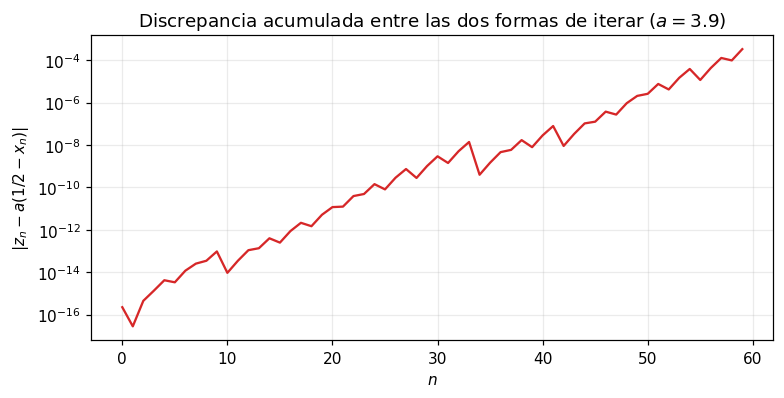

c = a(2-a)/4 = -1.8525
error tras 10 iteraciones: 9.54e-14
error tras 60 iteraciones: 3.40e-04


In [ ]:
# Iterando las dos órbitas paralelamente, caso caótico
a = 3.9
c = a * (2 - a) / 4
x, z = 0.31, a * (0.5 - 0.31)

errores = []
for n in range(60):
    x = f(x, a)
    z = z**2 + c
    errores.append(abs(z - a * (0.5 - x)))

plt.figure(figsize=(8, 3.6))
plt.semilogy(errores, color="tab:red")
plt.xlabel("$n$")
plt.ylabel(r"$|z_n - a(1/2 - x_n)|$")
plt.title(f"Discrepancia acumulada entre las dos formas de iterar ($a = {a}$)")
plt.show()

print(f"c = a(2-a)/4 = {c:.4f}")
print(f"error tras 10 iteraciones: {errores[9]:.2e}")
print(f"error tras 60 iteraciones: {errores[59]:.2e}")

La identidad se cumple a nivel de precisión de máquina en un solo paso, que es lo que había que
demostrar. La segunda gráfica muestra algo que si iteramos 
las dos órbitas en paralelo durante 60 pasos, la diferencia entre ellas crece de $10^{-16}$ a algo
del orden de $10^{-4}$. Las dos
órbitas son matemáticamente iguales pero se calculan con operaciones distintas, y la diferencia de
redondeo en el último bit se amplifica exponencialmente porque $a = 3.9$ está en la zona caótica, en una que no lo fuera no crecería. 

### Las dos figuras, una encima de la otra

Como $c = a(2-a)/4$ es una función monótona decreciente de $a$ para $a > 1$, dibujemos el
diagrama de bifurcaciones usando $c$ en el eje horizontal en lugar de $a$, y lo ponemos justo arriba
de la franja real del conjunto de Mandelbrot.

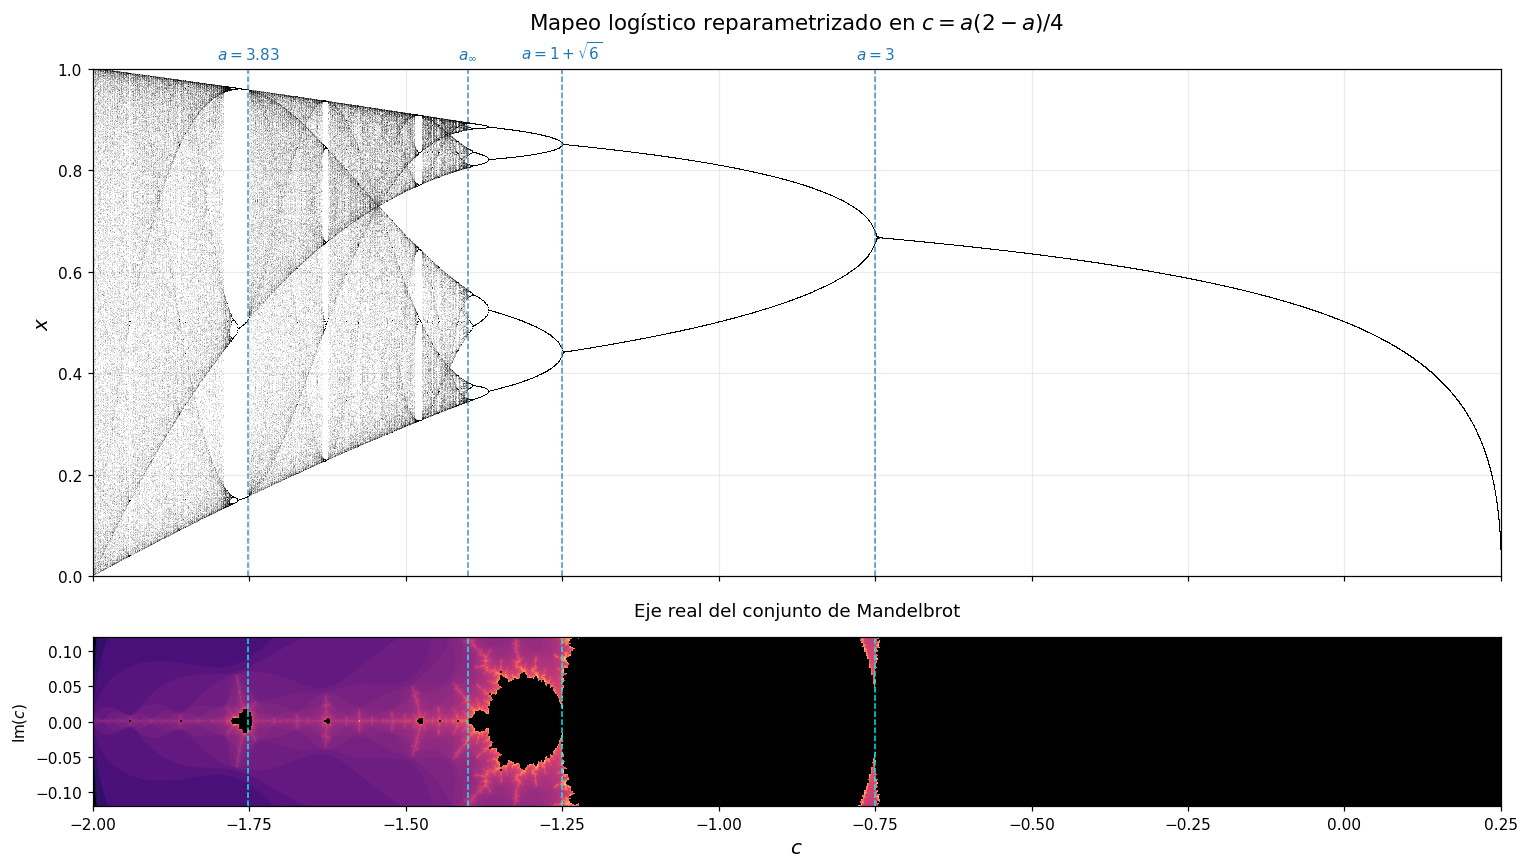

In [44]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# Diagrama de bifurcaciones reparametrizado en c
a = np.linspace(1.0, 4.0, 4000)
c = a * (2 - a) / 4
x = np.full_like(a, 0.5)

for _ in range(600):
    x = a * x * (1 - x)
for _ in range(300):
    x = a * x * (1 - x)
    ax1.plot(c, x, ",k", alpha=0.12)

ax1.set_ylim(0, 1)
ax1.set_ylabel("$x$", fontsize=13)
ax1.set_title("Mapeo logístico reparametrizado en $c = a(2-a)/4$", fontsize=14, pad=26)

extent_c = (-2.0, 0.25, -0.12, 0.12)
esc_c = mandelbrot(*extent_c, ancho=1600, alto=250, max_iter=400)
dibujar(ax2, esc_c, extent_c, 400, "Eje real del conjunto de Mandelbrot")

marcas = [(-0.75, "$a=3$"), (-1.25, r"$a=1+\sqrt{6}$"),
          (-1.4011, r"$a_\infty$"), (-1.7522, "$a=3.83$")]
for c_marca, nombre in marcas:
    ax1.axvline(c_marca, color="tab:blue", lw=1, ls="--", alpha=0.8)
    ax2.axvline(c_marca, color="cyan", lw=1, ls="--", alpha=0.9)
    ax1.text(c_marca, 1.02, nombre, ha="center", fontsize=10, color="tab:blue")

ax1.set_xlim(-2.0, 0.25)
ax2.set_xlabel("$c$", fontsize=13)
fig.tight_layout()
plt.show()

Con la correspondencia $c = a(2-a)/4$ los valores de $a$ usados se traducen así:

| $a$ | $c = a(2-a)/4$ | mapeo logístico | conjunto de Mandelbrot |
|:---:|:---:|:--|:--|
| $1$ | $+0.25$ | nace el punto fijo no trivial | punta derecha de la cardioide |
| $2.8$ | $-0.56$ | punto fijo estable | dentro de la cardioide |
| $3$ | $-0.75$ | primera duplicación | unión cardioide–disco |
| $3.2$ | $-0.96$ | periodo 2 | dentro del disco |
| $1+\sqrt{6} \approx 3.4495$ | $-1.25$ | segunda duplicación | borde izquierdo del disco |
| $3.5$ | $-1.3125$ | periodo 4 | bulbo de periodo 4 |
| $a_\infty \approx 3.5699$ | $-1.4011$ | acumulación de Feigenbaum | punto de Myrberg–Feigenbaum |
| $3.83$ | $-1.7522$ | ventana de periodo 3 | bulbo aislado grande |
| $4$ | $-2$ | caos en todo $[0,1]$ | punta izquierda del conjunto |

Los dos diagramas describen lo mismo. Cada periodo del diagrama de bifurcaciones corresponde a una
componente del conjunto de Mandelbrot sobre el eje real: el punto fijo es la cardioide, el periodo 2
es el disco pegado a ella, el periodo 4 es el bulbo siguiente, y así sucesivamente. Cuando el
atractor deja de ser finito ($a_\infty$) terminan las componentes redondas y empiezan los
filamentos. La ventana de periodo 3 cae sobre el bulbo aislado en $c \approx -1.75$

Esto, dado que un valor de $a$ y su $c$ correspondiente son la misma dinámica escrita en otras coordenadas, y un cambio de coordenadas no altera cuántos puntos tiene un ciclo ni si es estable, es decir, lo que en una figura es un bulbo de periodo 4, en la otra es un tramo con cuatro ramas. El conjunto de Mandelbrot es el diagrama de bifurcaciones sacado al plano complejo: la recta real es la rebanada donde está el mapeo logístico, y todo lo demás es la parte del parámetro que nunca llegamos a ver desde ahí.

## 6. Discusión

Lo que cambia al aumentar $a$ no es la cantidad de movimiento sino cuántos estados termina visitando
el sistema: para $a < 1$ todo se acaba en cero, entre $1$ y $3$ hay un punto fijo que atrae casi todo,
y a partir de ahí el atractor se parte en $2$, $4$, $8$, ... hasta dejar de ser finito. Lo notable es
que el mapeo nunca cambia de forma: es la misma parábola, sólo más alta. Todo sale de que al
estirarse, la pendiente en los puntos del ciclo pasa de magnitud menor que $1$ a mayor que $1$, y el
ciclo que atraía empieza a repeler.

Reconocer una órbita periódica es distinto en cada representación. En la serie temporal bunucasmos un
patrón repetido, lo cual sirve para periodo 2 o 4 y deja de ser fiable en cuanto el periodo sube. En
el cobweb buscamos una figura cerrada. En el diagrama de bifurcaciones, cuántas ramas cruza una vertical. Terminamos programando la detección numérica. 

El caos se reconoce por dos razones unidsas. Una es negativa: la órbita no se repite ni
se asienta, el cobweb no cierra figura, el diagrama muestra una banda continua. La otra es positiva: dos órbitas separadas por $10^{-4}$ con $a = 3.9$ se vuelven irreconocibles en
menos de veinte iteraciones, y eso no le pasa a un ciclo de periodo alto.

Cuál gráfica sirve más depende del contexto. Para orientarse, el diagrama de bifurcaciones: es el que muestra todo el espacio de parámetros junto; para entender más claramente por qué ocurre lo que ocurre, el cobweb, ya que conecta el comportamiento con la geometría de la parábola y la diagonal. 

Sí puede reaparecer comportamiento periódico dentro del caos. La ventana
de periodo 3 en $a \approx 3.83$ mide unos $0.013$ de ancho, un intervalo entero, y al hacer zoom
aparece otra cascada $3 \to 6 \to 12$ que copia en miniatura el diagrama completo. Los
parámetros caóticos se vuelven más abundantes, pero los periódicos nunca desaparecen del todo. 

La relación con el conjunto de Mandelbrot es una igualdad, dado que el cambio de variable
$z_n = a(1/2 - x_n)$ convierte un mapeo en el otro con $c = a(2-a)/4$, así que el diagrama de
bifurcaciones y el eje real del Mandelbrot son dos dibujos del mismo dato: uno grafica los valores
del ciclo, el otro colorea el parámetro. Por estas razones, las duplicaciones coinciden con las uniones entre la cardioide y los discos, y la ventana de periodo 3 con el bulbo aislado en $c \approx -1.75$.

Eso último es lo que más me interesa por moticos un tanto indirectos. El mapeo logístico se lee
como un modelo de población; el conjunto de Mandelbrot salió de iterar polinomios complejos y no
tiene ninguna motivación física per se; quue la misma estructura aparezca en los dos, hasta en las
proporciones entre escalas, sugiere que no pertenece a ninguno de los dos problemas sino a la
operación de iterar una función con un máximo. La oleada de duplicaciones, en este sentido, parece ser un patrón que podemos buscar y esperar en muchos diagramas. 